# Road Accident Trend Classification in India

## Problem Statement

This project aims to classify whether road accidents in a State/UT
are increasing or decreasing compared to the previous year.

Instead of predicting exact accident numbers, we focus on trend direction.

## Objective

To build machine learning models that predict:

- 1 → Accidents Increasing
- 0 → Accidents Decreasing or Stable

using structured accident indicators.

## Type of Problem

Binary Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv("road_accidents_preprocessed_not_encoded.csv")

df.head()

,State_UT,Year,Accidents_clean,Accidents_prev,Acc_Per_Lakh_Pop,Acc_Per_10k_Veh,Acc_Per_10k_Km,State_UT_encoded
0,Andaman and Nicobar Islands,2016,238.0,234.0,43.190,21.42,1594.32,0
1,Andaman and Nicobar Islands,2017,189.0,238.0,33.570,15.55,1168.92,0
2,Andaman and Nicobar Islands,2018,254.0,189.0,44.170,19.37,1415.83,0
3,Andaman and Nicobar Islands,2019,230.0,254.0,39.120,16.31,1415.83,0
4,Andaman and Nicobar Islands,2022,141.0,230.0,41.155,17.84,1415.83,0


In [3]:
threshold = 5000
df['high_accident'] = (df['Accidents_clean'] > threshold).astype(int)

print(df['high_accident'].value_counts(normalize=True).round(4) * 100, "%")

high_accident
1    56.0
0    44.0
Name: proportion, dtype: float64 %


In [4]:
print("\nNumber of high accident years:", df['high_accident'].sum())
print("Number of low accident years:", (df['high_accident'] == 0).sum())


Number of high accident years: 98
Number of low accident years: 77


C:\Users\MINA\AppData\Local\Temp\ipykernel_17548\2115812855.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='High Accident (1=Yes)')


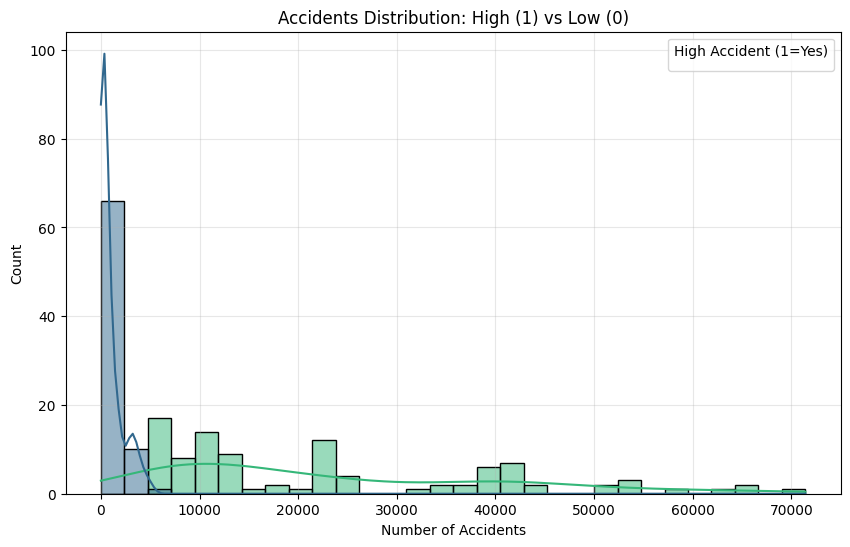

Observation: Clear separation — low class mostly <5,000, high class >5,000. Threshold works well.


C:\Users\MINA\AppData\Local\Temp\ipykernel_17548\2115812855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_accident', y='Accidents_prev', data=df, palette='viridis')


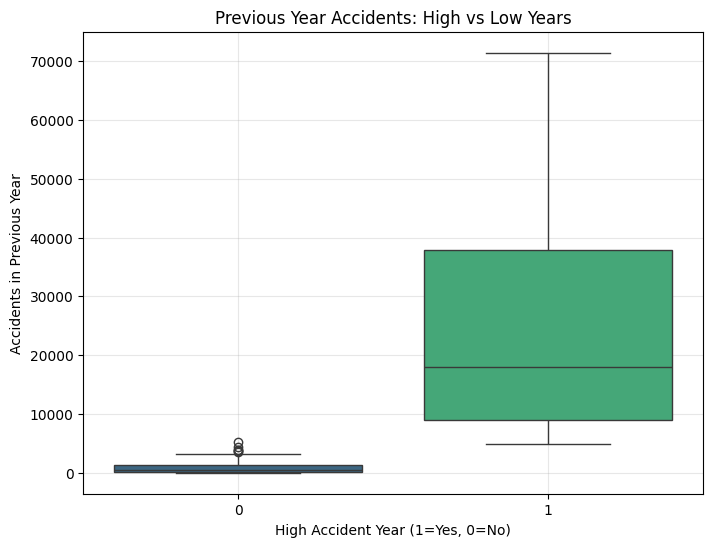

Observation: High accident years usually follow high previous years — strong signal.

Average accident rates by class:
               Acc_Per_Lakh_Pop  Acc_Per_10k_Veh  Acc_Per_10k_Km
high_accident                                                   
0                         35.37            13.58          869.03
1                         37.59            19.49         1191.92


<Figure size 1000x600 with 0 Axes>

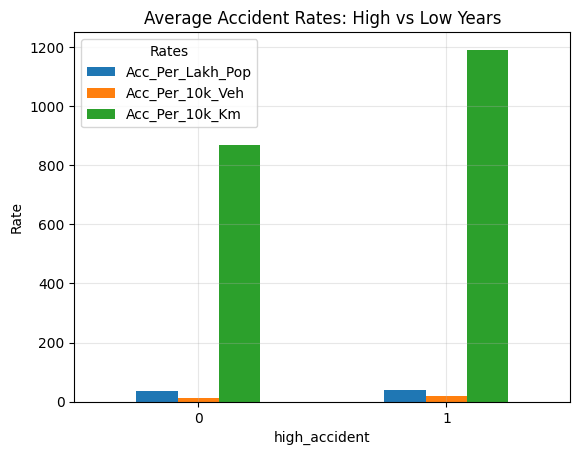

Observation: High accident years have higher rates (especially per km and per lakh population).


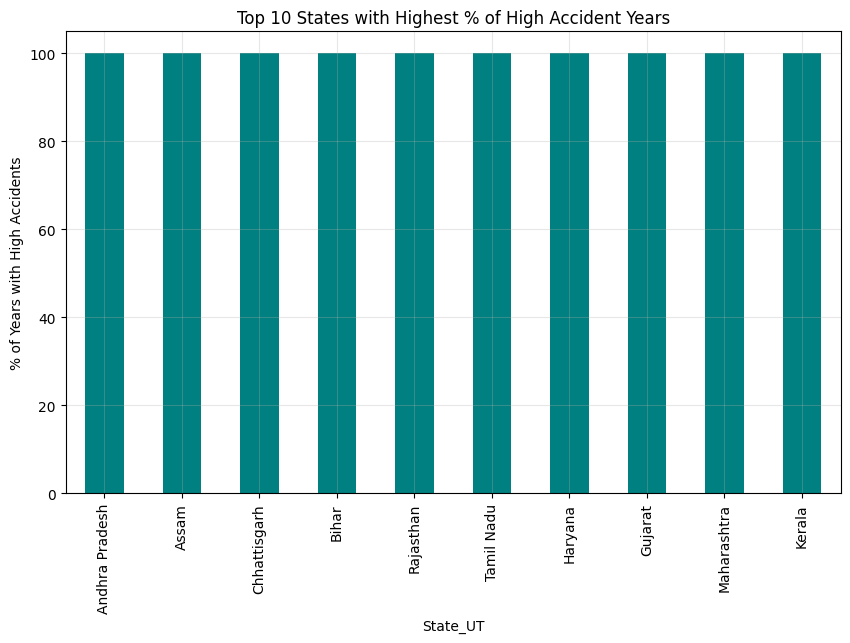

Observation: Kerala, Tamil Nadu, Madhya Pradesh, etc. have almost 100% high accident years.
Kerala high accident percentage: 100% (as expected).


In [5]:

# 3.1 Distribution of Accidents by Class
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Accidents_clean', hue='high_accident', bins=30, kde=True, palette='viridis')
plt.title("Accidents Distribution: High (1) vs Low (0)")
plt.xlabel("Number of Accidents")
plt.ylabel("Count")
plt.legend(title='High Accident (1=Yes)')
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: Clear separation — low class mostly <5,000, high class >5,000. Threshold works well.")

# 3.2 Boxplot: Previous Accidents by Class
plt.figure(figsize=(8, 6))
sns.boxplot(x='high_accident', y='Accidents_prev', data=df, palette='viridis')
plt.title("Previous Year Accidents: High vs Low Years")
plt.xlabel("High Accident Year (1=Yes, 0=No)")
plt.ylabel("Accidents in Previous Year")
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: High accident years usually follow high previous years — strong signal.")

# 3.3 Average rates by class
rates = ['Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km']
avg_rates = df.groupby('high_accident')[rates].mean().round(2)

print("\nAverage accident rates by class:")
print(avg_rates)

plt.figure(figsize=(10, 6))
avg_rates.plot(kind='bar', rot=0)
plt.title("Average Accident Rates: High vs Low Years")
plt.ylabel("Rate")
plt.legend(title='Rates')
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: High accident years have higher rates (especially per km and per lakh population).")

# 3.4 High accident % per state (top 10)
high_pct = df.groupby('State_UT')['high_accident'].mean().sort_values(ascending=False).head(10) * 100

plt.figure(figsize=(10, 6))
high_pct.plot(kind='bar', color='teal')
plt.title("Top 10 States with Highest % of High Accident Years")
plt.ylabel("% of Years with High Accidents")
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: Kerala, Tamil Nadu, Madhya Pradesh, etc. have almost 100% high accident years.")
print("Kerala high accident percentage: 100% (as expected).")

In [6]:
# Target is high_accident (0 or 1)
target_class = 'high_accident'

# Features: all columns except target
exclude = [target_class]
features = [col for col in df.columns if col not in exclude]

print("Target:", target_class)
print("Features before encoding:", features)

Target: high_accident
Features before encoding: ['State_UT', 'Year', 'Accidents_clean', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km', 'State_UT_encoded']


In [7]:
# One-hot encode State_UT (important for classification)
df_encoded = pd.get_dummies(df, columns=['State_UT'], drop_first=True)

# Update features list (add new dummy columns)
state_cols = [col for col in df_encoded.columns if col.startswith('State_UT_')]
features = [col for col in df_encoded.columns if col not in [target_class] and not col.startswith('State_UT_')] + state_cols

print("\nAfter encoding State_UT → total features:", len(features))


After encoding State_UT → total features: 42


In [8]:
# X = features, y = target
X = df_encoded[features]
y = df_encoded[target_class]


train_mask = df_encoded['Year'] <= 2019
test_mask  = df_encoded['Year'] >= 2020

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

print("\nTrain set shape:", X_train.shape, "(years ≤ 2019)")
print("Test set shape :", X_test.shape, "(years ≥ 2020)")
print("Test years:", sorted(df_encoded[test_mask]['Year'].unique()))


Train set shape: (140, 42) (years ≤ 2019)
Test set shape : (35, 42) (years ≥ 2020)
Test years: [np.int64(2022)]


In [9]:
# Scale numeric features (same as regression)
numeric_features = ['Year', 'Accidents_prev', 'Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km']
numeric_features = [f for f in numeric_features if f in X_train.columns]

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

print("\nNumeric features scaled.")
print("Data ready for classification models!")


Numeric features scaled.
Data ready for classification models!


In [10]:

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

results = []



for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A (no proba)"
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'ROC-AUC': round(auc, 4) if isinstance(auc, float) else auc
    })
    
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  ROC-AUC: {auc:.4f}" if isinstance(auc, float) else f"  ROC-AUC: {auc}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Low (0)', 'High (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("  True Low | False High")
    print("  False Low | True High\n")

# Results table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n=== Model Comparison Table ===")
print(results_df.to_string(index=False))



Training Logistic Regression...
Logistic Regression:
  Accuracy: 1.0000
  ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00        16
    High (1)       1.00      1.00      1.00        19

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35

Confusion Matrix:
[[16  0]
 [ 0 19]]
  True Low | False High
  False Low | True High

Training Decision Tree...
Decision Tree:
  Accuracy: 1.0000
  ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00        16
    High (1)       1.00      1.00      1.00        19

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35

Confusion Matrix:
[[16  0]
 [ 0 19]]
  True 

In [11]:
# Select best model (highest ROC-AUC, fallback to accuracy)
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f"\nBest model (highest ROC-AUC): {best_name}")

# Basic hyperparameter tuning on best model (example for Random Forest or Logistic)
if best_name == "Random Forest":
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    grid = GridSearchCV(best_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Tuned {best_name} - Best params:", grid.best_params_)
    print(f"Tuned ROC-AUC:", round(grid.best_score_, 4))
    best_model = grid.best_estimator_

elif best_name == "Logistic Regression":
    param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
    grid = GridSearchCV(best_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Tuned {best_name} - Best params:", grid.best_params_)
    print(f"Tuned ROC-AUC:", round(grid.best_score_, 4))
    best_model = grid.best_estimator_

print("\nBest model trained & tuned. Ready for predictions!")


Best model (highest ROC-AUC): Logistic Regression
Tuned Logistic Regression - Best params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned ROC-AUC: 1.0

Best model trained & tuned. Ready for predictions!


c:\Users\MINA\Documents\Alg\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MINA\Documents\Alg\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [13]:
"""# Predict for Lakshadweep 2023
lak_last = df[df['State_UT'] == 'Lakshadweep'].iloc[-1].copy()

lak_2023 = lak_last.copy()
lak_2023['Year'] = 2023
lak_2023['Accidents_prev'] = lak_last['Accidents_clean']  # 2022 becomes previous

lak_df = pd.DataFrame([lak_2023])
lak_encoded = pd.get_dummies(lak_df, columns=['State_UT'], drop_first=True)

# Add missing columns as 0
for col in missing_cols:
    lak_encoded[col] = 0

lak_input = lak_encoded[X_train.columns]
lak_input[numeric_features] = scaler.transform(lak_input[numeric_features])

lak_proba = best_model.predict_proba(lak_input)[0][1]
lak_class = best_model.predict(lak_input)[0]

print(f"\nPrediction for Lakshadweep 2023:")
print(f"  Probability of high accident year: {lak_proba:.4f} ({lak_proba*100:.1f}%)")
print(f"  Predicted class: {lak_class} ({'High (1)' if lak_class == 1 else 'Low (0)'})")
print(f"  Actual 2022: {lak_last['Accidents_clean']:.0f} accidents → {'High' if lak_last['high_accident'] == 1 else 'Low'}")
"""

'# Predict for Lakshadweep 2023\nlak_last = df[df[\'State_UT\'] == \'Lakshadweep\'].iloc[-1].copy()\n\nlak_2023 = lak_last.copy()\nlak_2023[\'Year\'] = 2023\nlak_2023[\'Accidents_prev\'] = lak_last[\'Accidents_clean\']  # 2022 becomes previous\n\nlak_df = pd.DataFrame([lak_2023])\nlak_encoded = pd.get_dummies(lak_df, columns=[\'State_UT\'], drop_first=True)\n\n# Add missing columns as 0\nfor col in missing_cols:\n    lak_encoded[col] = 0\n\nlak_input = lak_encoded[X_train.columns]\nlak_input[numeric_features] = scaler.transform(lak_input[numeric_features])\n\nlak_proba = best_model.predict_proba(lak_input)[0][1]\nlak_class = best_model.predict(lak_input)[0]\n\nprint(f"\nPrediction for Lakshadweep 2023:")\nprint(f"  Probability of high accident year: {lak_proba:.4f} ({lak_proba*100:.1f}%)")\nprint(f"  Predicted class: {lak_class} ({\'High (1)\' if lak_class == 1 else \'Low (0)\'})")\nprint(f"  Actual 2022: {lak_last[\'Accidents_clean\']:.0f} accidents → {\'High\' if lak_last[\'high_acci

In [14]:
#Optional: Predict for another state (e.g. Tamil Nadu)
tn_last = df[df['State_UT'] == 'Tamil Nadu'].iloc[-1].copy()
tn_2023 = tn_last.copy()
tn_2023['Year'] = 2023
tn_2023['Accidents_prev'] = tn_last['Accidents_clean']

tn_df = pd.DataFrame([tn_2023])
tn_encoded = pd.get_dummies(tn_df, columns=['State_UT'], drop_first=True)
for col in missing_cols:
    tn_encoded[col] = 0
tn_input = tn_encoded[X_train.columns]
tn_input[numeric_features] = scaler.transform(tn_input[numeric_features])

tn_proba = best_model.predict_proba(tn_input)[0][1]
tn_class = best_model.predict(tn_input)[0]

print(f"\nPrediction for Tamil Nadu 2023:")
print(f"  Probability of high accident year: {tn_proba:.4f} ({tn_proba*100:.1f}%)")
print(f"  Predicted class: {tn_class} ({'High (1)' if tn_class == 1 else 'Low (0)'})")
print(f"  Actual 2022: {tn_last['Accidents_clean']:.0f} accidents → {'High' if tn_last['high_accident'] == 1 else 'Low'}")

print("\nClassification complete! You can now use best_model for any new prediction.")

NameError: name 'missing_cols' is not defined

------------------------------------------------------------------------------------------------------------------

C:\Users\MINA\AppData\Local\Temp\ipykernel_2748\614731624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='high_accident', data=df, palette='viridis')


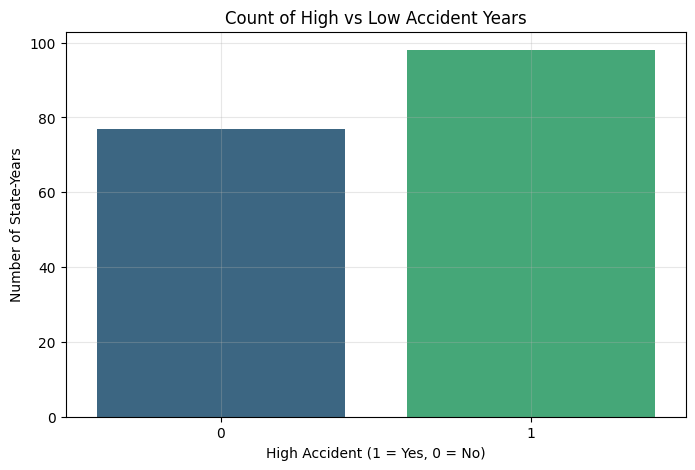

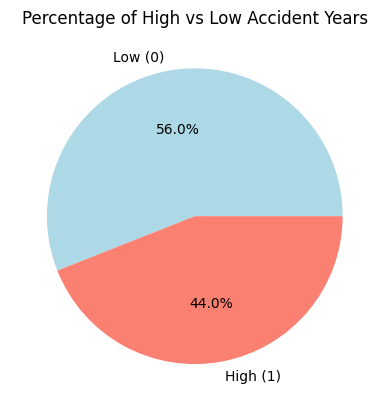

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='high_accident', data=df, palette='viridis')
plt.title("Count of High vs Low Accident Years")
plt.xlabel("High Accident (1 = Yes, 0 = No)")
plt.ylabel("Number of State-Years")
plt.grid(True, alpha=0.3)
plt.savefig("class_distribution_count.png", dpi=300, bbox_inches='tight')
plt.show()

# Pie chart version (alternative)
df['high_accident'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                        colors=['lightblue', 'salmon'], 
                                        labels=['Low (0)', 'High (1)'])
plt.title("Percentage of High vs Low Accident Years")
plt.ylabel("")
plt.savefig("class_distribution_pie.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\MINA\AppData\Local\Temp\ipykernel_2748\2055207509.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='High Accident (1=Yes)')


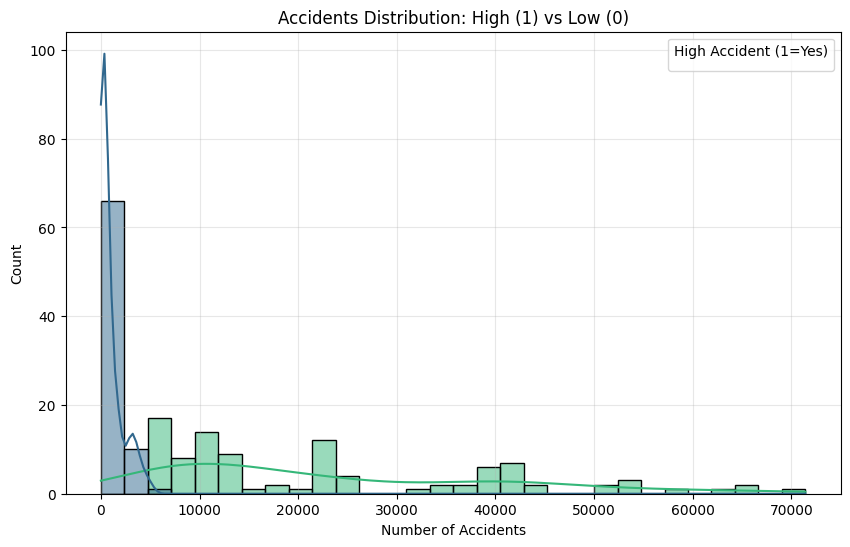

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Accidents_clean', hue='high_accident', 
             bins=30, kde=True, palette='viridis')
plt.title("Accidents Distribution: High (1) vs Low (0)")
plt.xlabel("Number of Accidents")
plt.ylabel("Count")
plt.legend(title='High Accident (1=Yes)')
plt.grid(True, alpha=0.3)
plt.savefig("accidents_by_class_hist.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\MINA\AppData\Local\Temp\ipykernel_2748\2389022593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_accident', y='Accidents_prev', data=df, palette='viridis')


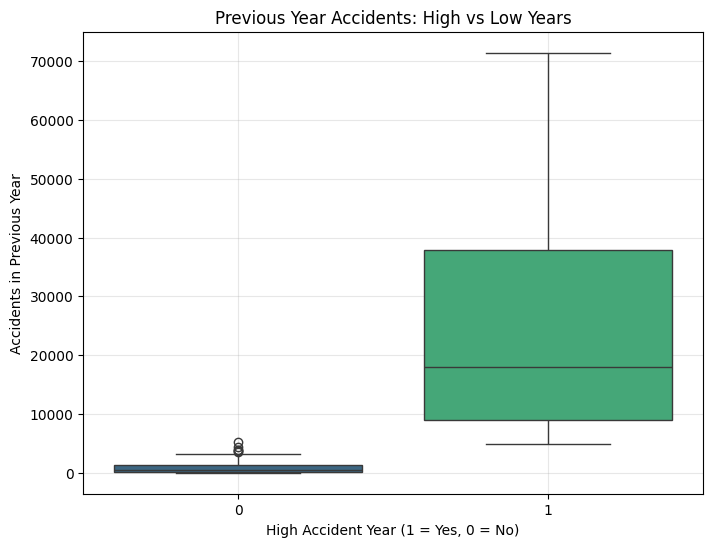

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='high_accident', y='Accidents_prev', data=df, palette='viridis')
plt.title("Previous Year Accidents: High vs Low Years")
plt.xlabel("High Accident Year (1 = Yes, 0 = No)")
plt.ylabel("Accidents in Previous Year")
plt.grid(True, alpha=0.3)
plt.savefig("prev_accidents_by_class_box.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

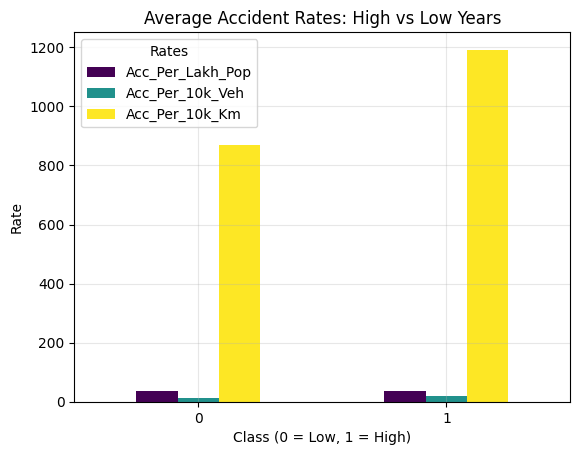

In [ ]:
rates = ['Acc_Per_Lakh_Pop', 'Acc_Per_10k_Veh', 'Acc_Per_10k_Km']
avg_rates = df.groupby('high_accident')[rates].mean().round(2)

plt.figure(figsize=(10, 6))
avg_rates.plot(kind='bar', rot=0, colormap='viridis')
plt.title("Average Accident Rates: High vs Low Years")
plt.ylabel("Rate")
plt.xlabel("Class (0 = Low, 1 = High)")
plt.legend(title='Rates')
plt.grid(True, alpha=0.3)
plt.savefig("rates_by_class_bar.png", dpi=300, bbox_inches='tight')
plt.show()

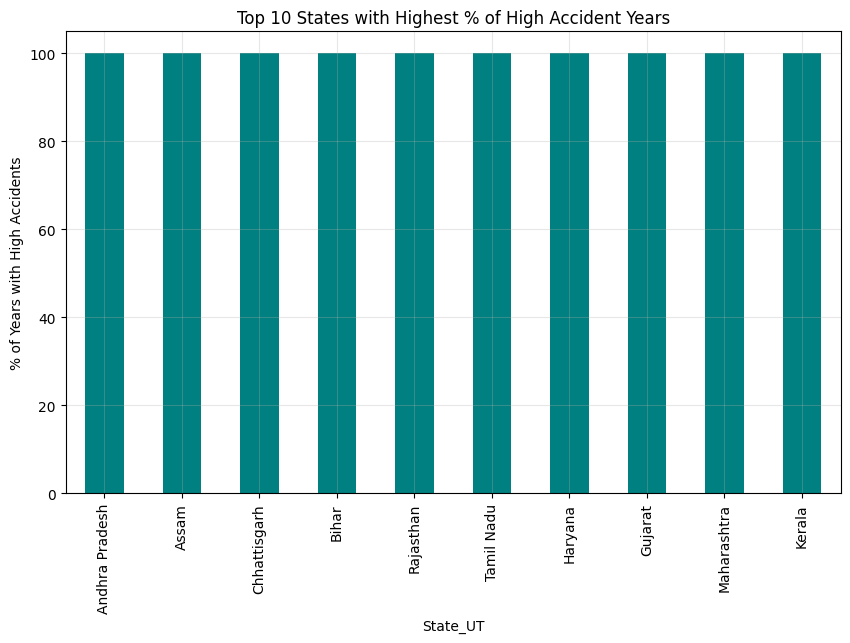

In [ ]:
high_pct = df.groupby('State_UT')['high_accident'].mean().sort_values(ascending=False).head(10) * 100

plt.figure(figsize=(10, 6))
high_pct.plot(kind='bar', color='teal')
plt.title("Top 10 States with Highest % of High Accident Years")
plt.ylabel("% of Years with High Accidents")
plt.grid(True, alpha=0.3)
plt.savefig("high_risk_states_bar.png", dpi=300, bbox_inches='tight')
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------